# Elasticity Dataset Checker

For one sample: plot model input geometry and target stress field on that geometry.


shapes: (65, 41, 2000) (65, 41, 2000) (65, 41, 2000)
sample_idx=4 | grid shape=(65, 41)
sigma range: 6.88501476100646 1592.6682279776287


/tmp/ipykernel_1062049/424698174.py:35: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = axes[1].pcolormesh(x_in, y_in, sigma_out, shading="auto", cmap="magma")


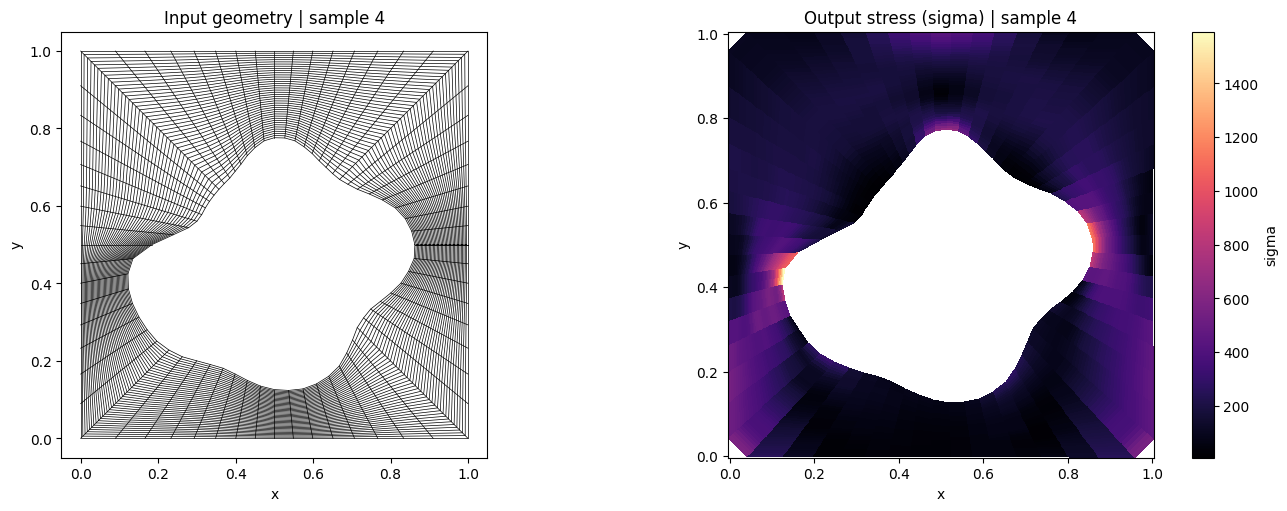

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.load("/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_X_10_interp.npy")
y = np.load("/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_Y_10_interp.npy")
sigma = np.load("/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_sigma_10_interp.npy")

print("shapes:", x.shape, y.shape, sigma.shape)
assert x.shape == y.shape == sigma.shape

# Sample index (last axis)
sample_idx = 4  # change as needed
assert 0 <= sample_idx < x.shape[-1]

x_in = x[:, :, sample_idx]
y_in = y[:, :, sample_idx]
sigma_out = sigma[:, :, sample_idx]

print(f"sample_idx={sample_idx} | grid shape={x_in.shape}")
print("sigma range:", float(sigma_out.min()), float(sigma_out.max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Input: geometry only (mesh lines, no stress coloring)
axes[0].set_title(f"Input geometry | sample {sample_idx}")
for i in range(x_in.shape[0]):
    axes[0].plot(x_in[i, :], y_in[i, :], color="black", lw=0.5)
for j in range(x_in.shape[1]):
    axes[0].plot(x_in[:, j], y_in[:, j], color="black", lw=0.5)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Output: same geometry with stress field visible
pcm = axes[1].pcolormesh(x_in, y_in, sigma_out, shading="auto", cmap="magma")
axes[1].set_title(f"Output stress (sigma) | sample {sample_idx}")
axes[1].set_aspect("equal")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(pcm, ax=axes[1], label="sigma")

plt.show()
